<a href="https://colab.research.google.com/github/bulah16/C5-Project/blob/main/Identifying_Key_Entities_in_Recipe_Data_MBulah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Identifying Key Entities in Recipe Data**

### Submitted by: **M. Bulah**

**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model classifies words into predefined categories such as `ingredient`, `quantity` and `unit`, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**.

| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags / NER labels, identifying quantities, ingredients, and units. |

### **Assumptions**
- Tokens in `input` and their corresponding labels in `pos` are aligned strictly by their position after a simple whitespace split; no additional tokenisation (e.g. splitting `2-1/2` into separate sub-tokens) is performed, since the label sequence is provided at the whitespace-token level.
- Rows where the number of `input` tokens does not equal the number of `pos` labels are treated as corrupted/misaligned records and are dropped, since there is no reliable way to re-align them.
- The three labels observed in the data (`ingredient`, `quantity`, `unit`) are treated as the complete label set — no additional/implicit labels (e.g. `O` for outside) are assumed.
- A 70:30 train-validation split with a fixed `random_state=42` is used for reproducibility; no separate held-out test set was supplied, so validation performance is used as the best available proxy for generalisation.
- spaCy's `en_core_web_sm` model is used for linguistic features (POS, lemma, dependency, shape) even though it is trained on general English text and not recipe text, since it still provides useful lexical/morphological signals.
- The "penalise ingredient label" instruction in the class-weighting step is implemented by halving the inverse-frequency weight computed for the majority `ingredient` class, so it is nudged down relative to the naturally rarer `quantity` and `unit` classes without removing its influence altogether.


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It integrates seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [1]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.6 MB/s eta 0:00:00


#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

# Set random seed for reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [4]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis*
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function**

In [5]:
# define a function to load json file to a dataframe
def load_json_dataframe(path):
    """
    Reads a JSON file containing recipe records and converts it into a pandas DataFrame.

    Parameters
    ----------
    path : str
        Path to the ingredient_and_quantity.json file.

    Returns
    -------
    pd.DataFrame
        DataFrame with the raw 'input' and 'pos' columns.
    """
    with open(path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    return df

##### **2.1.2** **Execute the *load_json_dataframe* function**

In [18]:
from google.colab import drive
drive.mount('/content/drive')

# Execute this cell to find the path of your JSON file within Google Drive
!find /content/drive -name "ingredient_and_quantity.json"
# read the json file by giving the file path and create a dataframe
df = load_json_dataframe('/content/drive/MyDrive/ingredient_and_quantity.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ingredient_and_quantity.json


##### **2.1.3** **Describe the dataframe**

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [19]:
# display first five rows of the dataframe - df
df.head()

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [20]:
# print the dimensions of dataframe - df
print(f"Dimensions of the dataframe (rows, columns): {df.shape}")

Dimensions of the dataframe (rows, columns): (285, 2)


In [21]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation*
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe**
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [22]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input
df['input_tokens'] = df['input'].apply(lambda x: x.split())
# Tokenize POS
df['pos_tokens'] = df['pos'].apply(lambda x: x.split())

In [23]:
# display first five rows of the dataframe - df
df[['input', 'pos', 'input_tokens', 'pos_tokens']].head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length**

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length

In [24]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

In [25]:
# check for the equality of input_length and pos_length in the dataframe
mismatch_mask = df['input_length'] != df['pos_length']
mismatched_rows = df[mismatch_mask]
print(f"Number of rows with mismatched input/pos lengths: {len(mismatched_rows)}")
mismatched_rows[['input', 'pos', 'input_length', 'pos_length']]

Number of rows with mismatched input/pos lengths: 5


,input,pos,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,54,53
207,1 cup Cashew nuts Badam Almond 1 1/4 cups Sugar 1/2 Water teaspoon Cardamom Powder Ghee for greasing,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient quantity ingredient unit ingredient ingredient ingredient unit ingredient,18,17


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens**

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.

In [26]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(df, col='pos_tokens'):
    """Return the set of unique labels present across all pos_tokens sequences."""
    labels = set()
    for toks in df[col]:
        labels.update(toks)
    return labels

recipe_labels = unique_labels(df)
print(f"Unique labels present in the recipe data: {recipe_labels}")

Unique labels present in the recipe data: {'quantity', 'unit', 'ingredient'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation**

Provide the indexes that requires cleaning and formatting in the dataframe

In [27]:
invalid_idx = df[mismatch_mask].index.tolist()
print(f"Indexes that require cleaning/formatting (input_length != pos_length): {invalid_idx}")

Indexes that require cleaning/formatting (input_length != pos_length): [17, 27, 79, 164, 207]


**Insights:**
- The label set is clean and consistent — only the three expected labels (`ingredient`, `quantity`, `unit`) are present across the entire dataset; there are no stray or misspelled labels.
- 5 out of 285 records (indexes **17, 27, 79, 164, 207**) have a mismatch between the number of `input` tokens and the number of `pos` labels. These records cannot be reliably aligned token-to-label and must be removed before model training, since a CRF requires a label for every token in the sequence.
- This leaves 280 clean, fully-aligned records for downstream analysis and modelling.

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell**

In [28]:
# drop the irrelevant recipe data
df = df.drop(index=invalid_idx).reset_index(drop=True)
print(f"Shape of dataframe after dropping invalid rows: {df.shape}")

Shape of dataframe after dropping invalid rows: (280, 6)


##### **2.2.5** **Update the input_length & pos_length in dataframe**

In [29]:
# update the input and pos length in input_length and pos_length
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows**

In [30]:
# validate the input length and pos length as input_length and pos_length
remaining_mismatches = df[df['input_length'] != df['pos_length']]
print(f"Remaining mismatched rows after cleaning: {len(remaining_mismatches)}")
assert len(remaining_mismatches) == 0, "There are still mismatched rows!"
print("All rows now have matching input_length and pos_length.")

Remaining mismatched rows after cleaning: 0
All rows now have matching input_length and pos_length.


## **3** Train Validation Split (70 train - 30 val)

#### **3.1** *Perform train and validation split ratio*
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio**

In [31]:
# split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training set size: {train_df.shape[0]} recipes")
print(f"Validation set size: {val_df.shape[0]} recipes")

Training set size: 196 recipes
Validation set size: 84 recipes


###### **3.1.2** **Print the first five rows of train_df and val_df**

In [32]:
# print the first five rows of train_df
train_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
2,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
3,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, 

In [33]:
# print the first five rows of the val_df
val_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
1,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
2,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
3,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient ingredie

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length**

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [34]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()

X_val = val_df['input_tokens'].tolist()
y_val = val_df['pos_tokens'].tolist()

In [35]:
# validate the shape of training and validation samples
print(f"X_train length: {len(X_train)}, y_train length: {len(y_train)}")
print(f"X_val length: {len(X_val)}, y_val length: {len(y_val)}")

X_train length: 196, y_train length: 196
X_val length: 84, y_val length: 84


###### **3.1.4** **Display the number of unique labels present in y_train**

In [36]:
# Display the number of unique labels present in y_train
y_train_unique_labels = set(label for seq in y_train for label in seq)
print(f"Number of unique labels in y_train: {len(y_train_unique_labels)}")
print(f"Unique labels in y_train: {y_train_unique_labels}")

Number of unique labels in y_train: 3
Unique labels in y_train: {'quantity', 'unit', 'ingredient'}


## **4** Exploratory Recipe Data Analysis on Training Dataset

#### **4.1** *Flatten the lists for input_tokens & pos_tokens*

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***

In [37]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    """Flattens a list of lists into a single flat list."""
    return [item for sublist in nested_list for item in sublist]

In [38]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique*

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function

In [39]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens
def extract_and_validate_tokens(df, dataset_name):
    input_tokens = flatten_list(df['input_tokens'].tolist())
    pos_tokens = flatten_list(df['pos_tokens'].tolist())

    assert len(input_tokens) == len(pos_tokens), f"Token/label length mismatch in {dataset_name} set!"

    print(f"--- {dataset_name} dataset ---")
    print(f"Total tokens: {len(input_tokens)}")
    print(f"First 10 input tokens: {input_tokens[:10]}")
    print(f"First 10 pos tokens:   {pos_tokens[:10]}")

    return input_tokens, pos_tokens

In [40]:
# extract the tokens and its pos tags
train_tokens, train_pos_tags = extract_and_validate_tokens(train_df, dataset_name)

--- Training dataset ---
Total tokens: 7114
First 10 input tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First 10 pos tokens:   ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)*

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.

In [41]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
def categorize_tokens(tokens, pos_tags):
    ingredients, units, quantities = [], [], []

    if len(tokens) != len(pos_tags):
        return [], [], []

    for token, tag in zip(tokens, pos_tags):
        if tag == 'ingredient':
            ingredients.append(token)
        elif tag == 'unit':
            units.append(token)
        elif tag == 'quantity':
            quantities.append(token)

    return ingredients, units, quantities

In [42]:
#  call the function to categorise the labels into respective list
train_ingredients, train_units, train_quantities = categorize_tokens(train_tokens, train_pos_tags)

print(f"Number of ingredient tokens: {len(train_ingredients)}")
print(f"Number of unit tokens: {len(train_units)}")
print(f"Number of quantity tokens: {len(train_quantities)}")

Number of ingredient tokens: 5323
Number of unit tokens: 811
Number of quantity tokens: 980


#### **4.4** *Top 10 Most Frequent Items*

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients

In [43]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
def get_top_frequent_items(item_list, label, dataset_name, top_n=10):
    counts = Counter(item_list)
    top_items = counts.most_common(top_n)

    print(f"Top {top_n} most frequent {label} in {dataset_name} data:")
    for item, count in top_items:
        print(f"  {item}: {count}")

    return top_items

In [44]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients_train = get_top_frequent_items(train_ingredients, 'ingredients', dataset_name)

Top 10 most frequent ingredients in Training data:
  powder: 129
  Salt: 102
  seeds: 89
  Green: 85
  chopped: 84
  Oil: 83
  Red: 81
  Chilli: 77
  Coriander: 71
  Sunflower: 65


In [45]:
# get the top units which are frequently seen in the recipe
top_units_train = get_top_frequent_items(train_units, 'units', dataset_name)

Top 10 most frequent units in Training data:
  teaspoon: 162
  cup: 136
  tablespoon: 99
  grams: 63
  tablespoons: 61
  inch: 52
  cups: 50
  sprig: 41
  cloves: 39
  teaspoons: 39


#### **4.5** *Plot Top 10 most frequent items*

Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [46]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(top_items, label, dataset_name, color='steelblue'):
    items, counts = zip(*top_items)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(items), color=color)
    plt.title(f'Top {len(top_items)} Most Frequent {label} - {dataset_name} Data')
    plt.xlabel('Frequency')
    plt.ylabel(label)
    plt.tight_layout()
    plt.show()

#### **4.6** *Perform EDA analysis*

Plot the bar plots for ingredients and units and provide the insights for training dataset

---

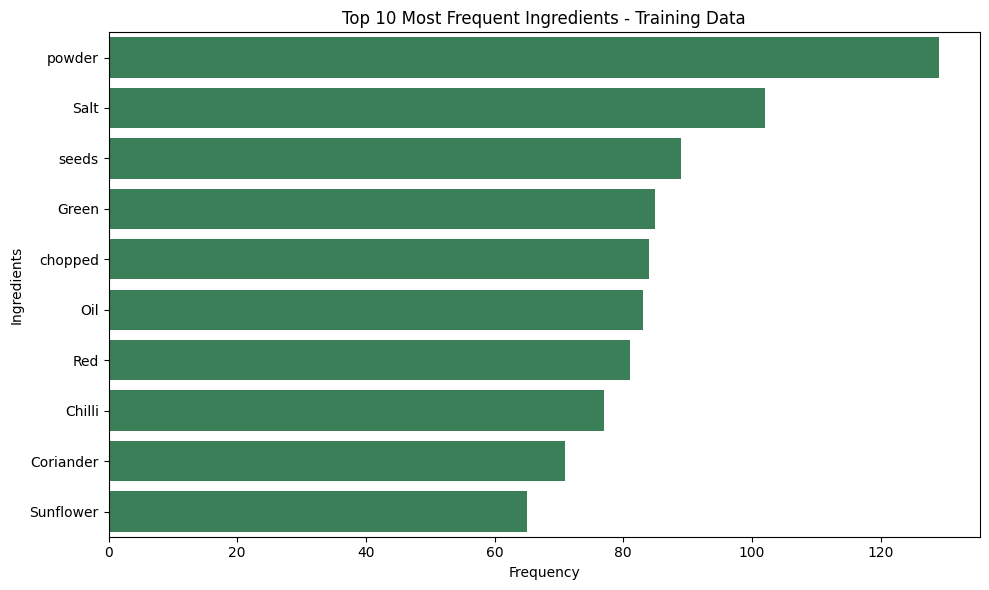

In [47]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients_train, 'Ingredients', dataset_name, color='seagreen')

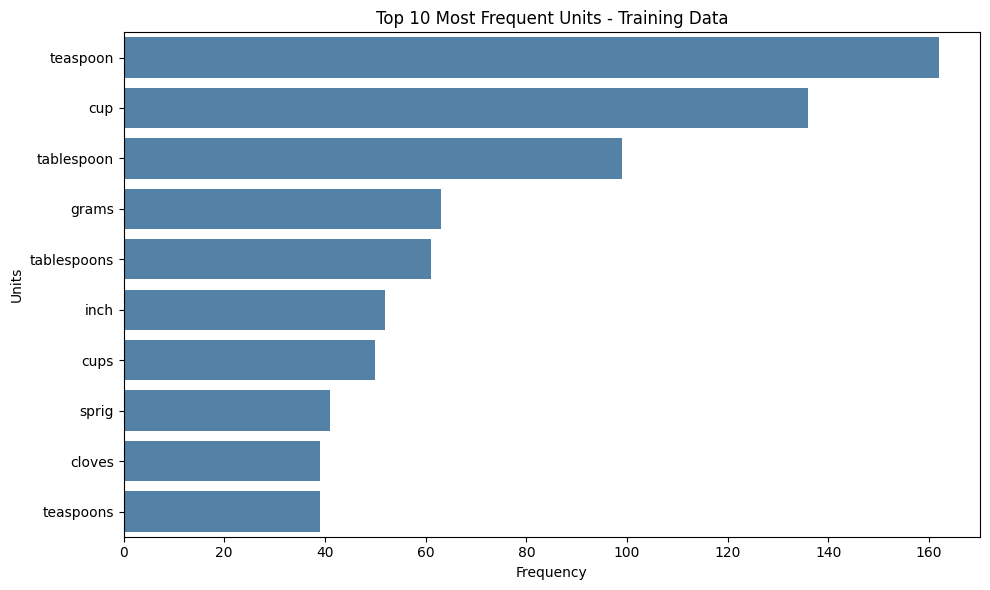

In [48]:
# plot the top frequent units in training data
plot_top_items(top_units_train, 'Units', dataset_name, color='steelblue')

**Insights from Training Dataset EDA:**
- `ingredient` is by far the most frequent label (~5,300 tokens), followed by `quantity` (~980) and `unit` (~810) — a class imbalance that must be handled during CRF training (see Section 6.4).
- The most frequent "ingredient" tokens are actually common descriptive/generic words that appear inside ingredient phrases — e.g. **powder**, **Salt**, **seeds**, **Green**, **chopped**, **Oil**, **Red**, **Chilli**, **Coriander**, **Sunflower** — reflecting that Indian recipes frequently reference spice powders (turmeric/chilli/coriander powder), salt, and chopped vegetables/oils.
- The most frequent units are **teaspoon, cup, tablespoon, grams, tablespoons, inch, cups, sprig, cloves, teaspoons** — standard Indian-kitchen measurement units, with volumetric spoon/cup measures dominating over weight-based ones (grams).
- The presence of both singular and plural forms of the same unit (e.g. `cup`/`cups`, `teaspoon`/`teaspoons`) as separate top items indicates that no lemmatisation/normalisation has been applied to the raw tokens — this is intentional at the EDA stage since the CRF operates on the original tokens, but the `lemma` feature engineered in Section 6 helps the model generalise across such variants.

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)*
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.

In [49]:
# initialise the dataset_name
dataset_name = 'Validation'

In [50]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
val_tokens, val_pos_tags = extract_and_validate_tokens(val_df, dataset_name)
val_ingredients, val_units, val_quantities = categorize_tokens(val_tokens, val_pos_tags)

top_ingredients_val = get_top_frequent_items(val_ingredients, 'ingredients', dataset_name)
top_units_val = get_top_frequent_items(val_units, 'units', dataset_name)

--- Validation dataset ---
Total tokens: 2876
First 10 input tokens: ['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']
First 10 pos tokens:   ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']
Top 10 most frequent ingredients in Validation data:
  powder: 54
  Salt: 47
  Oil: 39
  Red: 39
  seeds: 36
  Chilli: 36
  chopped: 31
  Green: 30
  Leaves: 29
  Coriander: 27
Top 10 most frequent units in Validation data:
  teaspoon: 59
  cup: 57
  tablespoon: 32
  tablespoons: 32
  cups: 24
  sprig: 21
  inch: 20
  grams: 19
  teaspoons: 18
  cloves: 16


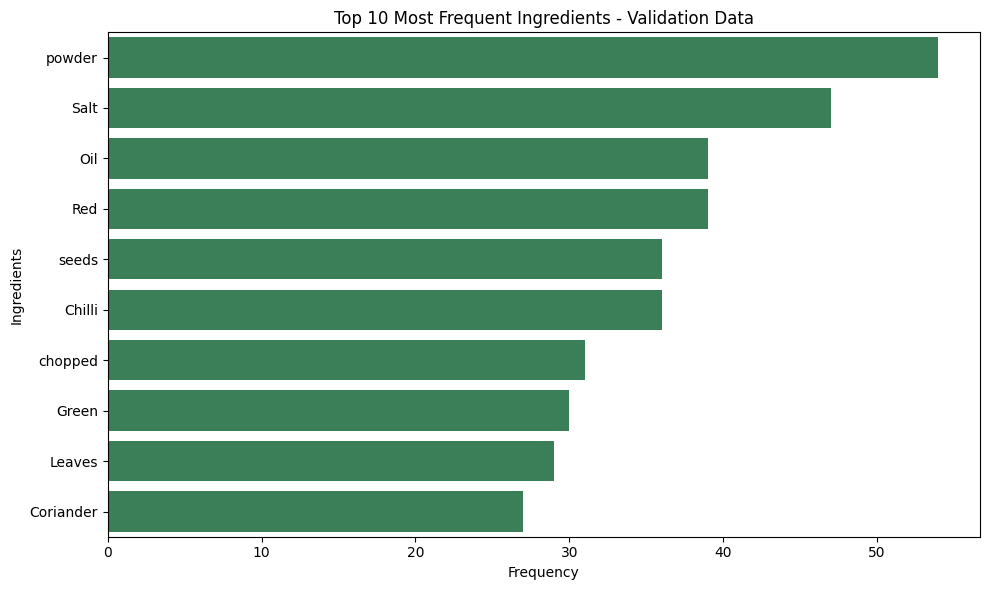

In [51]:
# plot the top frequent ingredients in validation data
plot_top_items(top_ingredients_val, 'Ingredients', dataset_name, color='seagreen')

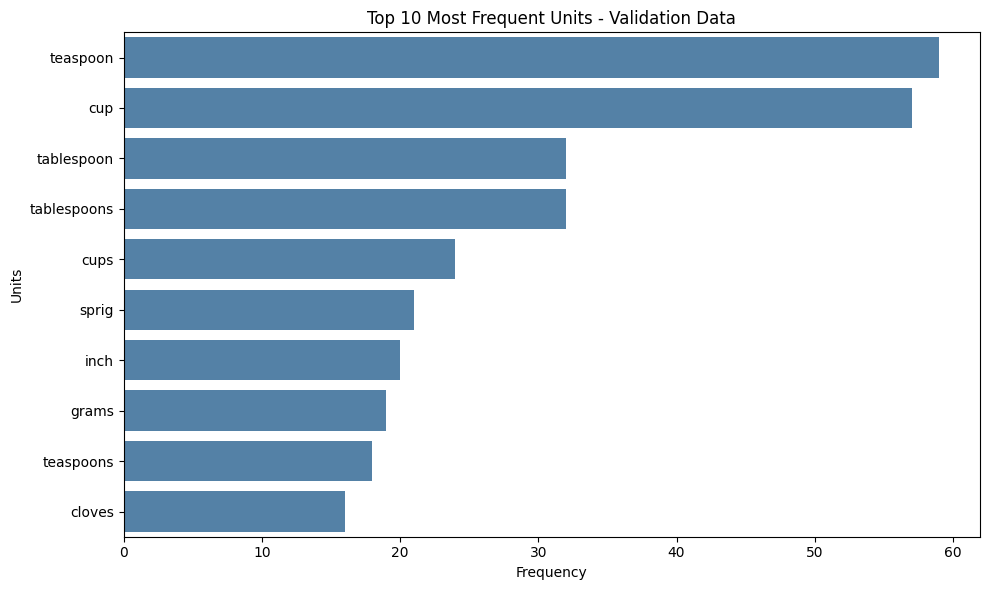

In [52]:
# plot the top frequent units in training data
plot_top_items(top_units_val, 'Units', dataset_name, color='steelblue')

**Insights from Validation Dataset EDA:**
- The validation set mirrors the training set's class distribution closely (`ingredient` >> `quantity` > `unit`), confirming that the random 70:30 split is representative and not skewed.
- The top ingredients and units in validation (powder, Salt, Oil, Red, seeds, Chilli, chopped, Green, Leaves, Coriander / teaspoon, cup, tablespoon, tablespoons, cups, sprig, inch, grams, teaspoons, cloves) are almost identical in composition to the training set's top items, which is a good sign for generalisation — the CRF is not being asked to generalise to a wildly different vocabulary in validation.

## **6** Feature Extraction For CRF Model

### **6.1** *Define a feature functions to take each token from recipe*

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals**

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [53]:
# define unit and quantity keywords along with quantity pattern
unit_keywords = {
    'cup', 'cups', 'tablespoon', 'tablespoons', 'tbsp', 'teaspoon', 'teaspoons', 'tsp',
    'gram', 'grams', 'g', 'kg', 'kilogram', 'kilograms', 'ml', 'milliliter', 'milliliters',
    'liter', 'liters', 'l', 'oz', 'ounce', 'ounces', 'lb', 'lbs', 'pound', 'pounds',
    'pinch', 'pinches', 'handful', 'inch', 'inches', 'clove', 'cloves', 'slice', 'slices',
    'piece', 'pieces', 'can', 'cans', 'packet', 'packets', 'stick', 'sticks', 'bunch',
    'bunches', 'sprig', 'sprigs', 'leaf', 'leaves', 'drop', 'drops', 'stalk', 'stalks'
}

quantity_keywords = {
    'half', 'quarter', 'few', 'some', 'dozen', 'pair', 'couple', 'whole', 'handful'
}

# Matches whole numbers, decimals, simple fractions (1/2) and mixed fractions (1-1/2, 2-1/2)
quantity_pattern = re.compile(r'^\d+(\.\d+)?$|^\d+/\d+$|^\d+-\d+/\d+$|^\d+\.\d+$')

In [54]:
# load spaCy model
nlp = spacy.load('en_core_web_sm')

##### **6.1.2** **Define feature functions for CRF**

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens.

In [55]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions
def word2features(sent, i, doc=None):
    # Process the entire sentence with spaCy (allow a pre-computed doc to be passed in for efficiency)
    if doc is None:
        doc = nlp(' '.join(sent))

    token = doc[i] if i < len(doc) else doc[-1]
    word = sent[i]
    word_lower = word.lower()

    # --- Core Features ---
    features = {
        'bias': 1.0,
        'token': word_lower,
        'lemma': token.lemma_.lower(),
        'pos_tag': token.pos_,
        'tag': token.tag_,
        'dep': token.dep_,
        'shape': token.shape_,
        'is_stop': token.is_stop,
        'is_digit': word.isdigit(),
        'has_digit': any(ch.isdigit() for ch in word),
        'has_alpha': any(ch.isalpha() for ch in word),
        'hyphenated': '-' in word,
        'slash_present': '/' in word,
        'is_title': word.istitle(),
        'is_upper': word.isupper(),
        'is_punct': token.is_punct,
    }

    # --- Improved Quantity & Unit Detection ---
    is_quantity = bool(quantity_pattern.match(word)) or word_lower in quantity_keywords
    is_unit = word_lower in unit_keywords
    is_numeric = word.replace('.', '', 1).isdigit()
    is_fraction = bool(re.match(r'^\d+/\d+$', word)) or bool(re.match(r'^\d+-\d+/\d+$', word))
    is_decimal = bool(re.match(r'^\d+\.\d+$', word))

    features.update({
        'is_quantity': is_quantity,
        'is_unit': is_unit,
        'is_numeric': is_numeric,
        'is_fraction': is_fraction,
        'is_decimal': is_decimal,
        'preceding_word': sent[i - 1].lower() if i > 0 else '',
        'following_word': sent[i + 1].lower() if i < len(sent) - 1 else '',
    })

    # --- Contextual Features ---
    if i > 0:
        prev_word = sent[i - 1]
        prev_word_lower = prev_word.lower()
        features.update({
            'prev_token': prev_word_lower,
            'prev_is_quantity': bool(quantity_pattern.match(prev_word)) or prev_word_lower in quantity_keywords,
            'prev_is_digit': prev_word.isdigit(),
        })
    else:
        features['BOS'] = True

    if i < len(sent) - 1:
        next_word = sent[i + 1]
        next_word_lower = next_word.lower()
        next_is_unit = next_word_lower in unit_keywords
        next_is_quantity = bool(quantity_pattern.match(next_word)) or next_word_lower in quantity_keywords
        features.update({
            'next_token': next_word_lower,
            'next_is_unit': next_is_unit,
            'next_is_ingredient': not (next_is_unit or next_is_quantity),
        })
    else:
        features['EOS'] = True

    return features

### **6.2** *Preparation of Recipe level features*

##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe**

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [56]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
    doc = nlp(' '.join(sent))  # process the sentence once for efficiency
    return [word2features(sent, i, doc=doc) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels*

##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val**

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [57]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(s) for s in X_train]
X_val_features = [sent2features(s) for s in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list**

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [58]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = [list(labels) for labels in y_train]
y_val_labels = [list(labels) for labels in y_val]

##### **6.3.3** **Print the length of val and train features and labels**

In [59]:
# print the length of train features and labels
print(f"X_train_features length: {len(X_train_features)}, y_train_labels length: {len(y_train_labels)}")

X_train_features length: 196, y_train_labels length: 196


In [60]:
# print the length of validation features and labels
print(f"X_val_features length: {len(X_val_features)}, y_val_labels length: {len(y_val_labels)}")

X_val_features length: 84, y_val_labels length: 84


### **6.4** *Applying weights to feature sets*

##### **6.4.1** **Flatten the labels of y_train**

Create ***y_train_flat*** to flatten the structure of nested y_train

In [61]:
# Flatten labels in y_train
y_train_flat = flatten_list(y_train_labels)

##### **6.4.2** **Count the labels present in training target dataset**

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [62]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print(f"Label counts in training data: {dict(label_counts)}")
print(f"Total samples: {total_samples}")

Label counts in training data: {'quantity': 980, 'unit': 811, 'ingredient': 5323}
Total samples: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights**

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [63]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
weight_dict = {label: total_samples / count for label, count in label_counts.items()}
print(f"Weights before penalising ingredient: {weight_dict}")

Weights before penalising ingredient: {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 1.336464399774563}


In [64]:
# penalise ingredient label
# 'ingredient' is the majority class, so its inverse-frequency weight is halved to avoid
# over-correcting the model and drowning out the signal for the minority classes
weight_dict['ingredient'] = weight_dict['ingredient'] * 0.5
print(f"Final weight_dict (after penalising ingredient): {weight_dict}")

Final weight_dict (after penalising ingredient): {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 0.6682321998872816}


##### **6.4.4** **Extract features along with class weights**

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights

In [65]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict):
    """
    Takes already-computed per-token feature dictionaries (X) and their true labels (y),
    and augments each token's feature dictionary with a 'class_weight' feature reflecting
    the inverse-frequency weight of its true label. This lets the CRF implicitly account
    for label imbalance while training.
    """
    X_weighted = []
    for sent_features, sent_labels in zip(X, y):
        weighted_sent = []
        for feats, label in zip(sent_features, sent_labels):
            feats = dict(feats)
            feats['class_weight'] = weight_dict.get(label, 1.0)
            weighted_sent.append(feats)
        X_weighted.append(weighted_sent)
    return X_weighted

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets**

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [66]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(X_train_features, y_train_labels, weight_dict)
X_val_weighted_features = extract_features_with_class_weights(X_val_features, y_val_labels, weight_dict)

print("Example weighted feature dictionary for the first token of the first training recipe:")
X_train_weighted_features[0][0]

Example weighted feature dictionary for the first token of the first training recipe:


{'bias': 1.0,
 'token': '250',
 'lemma': '250',
 'pos_tag': 'NUM',
 'tag': 'CD',
 'dep': 'nummod',
 'shape': 'ddd',
 'is_stop': False,
 'is_digit': True,
 'has_digit': True,
 'has_alpha': False,
 'hyphenated': False,
 'slash_present': False,
 'is_title': False,
 'is_upper': False,
 'is_punct': False,
 'is_quantity': True,
 'is_unit': False,
 'is_numeric': True,
 'is_fraction': False,
 'is_decimal': False,
 'preceding_word': '',
 'following_word': 'grams',
 'BOS': True,
 'next_token': 'grams',
 'next_is_unit': True,
 'next_is_ingredient': False,
 'class_weight': 7.259183673469388}

## **7** Model Building and Training

### **7.1** *Initialise the CRF model and train it*
Train the CRF model with the specified hyperparameters:

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF

In [67]:
# initialise CRF model with the specified hyperparameters and use weight_dict
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True
)

# train the CRF model with the weighted training data
crf.fit(X_train_weighted_features, y_train_labels)
print("CRF model training complete.")
print(f"Labels learnt by the model: {list(crf.classes_)}")

CRF model training complete.
Labels learnt by the model: ['quantity', 'unit', 'ingredient']


### **7.2** *Evaluation of Training Dataset using CRF model*
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [68]:
# evaluate on the training dataset
y_pred_train = crf.predict(X_train_weighted_features)
labels_list = list(crf.classes_)

In [69]:
# specify the flat classification report by using training data for evaluation
print("Classification Report - Training Dataset")
print(flat_classification_report(y_train_labels, y_pred_train, labels=labels_list, digits=3))

Classification Report - Training Dataset
              precision    recall  f1-score   support

    quantity      1.000     0.996     0.998       980
        unit      0.995     1.000     0.998       811
  ingredient      1.000     1.000     1.000      5323

    accuracy                          0.999      7114
   macro avg      0.998     0.999     0.998      7114
weighted avg      0.999     0.999     0.999      7114



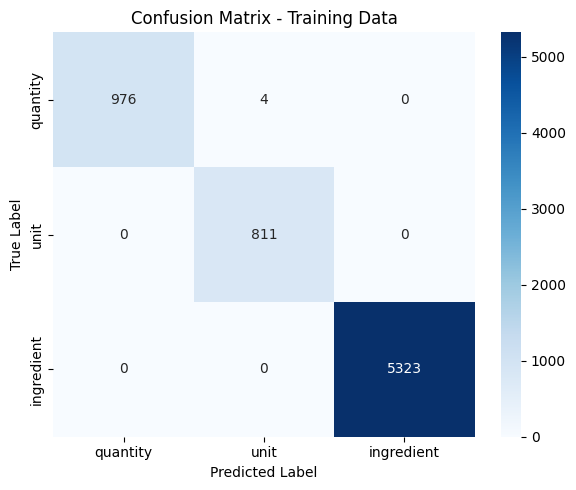

In [70]:
# create a confusion matrix on training datset
y_train_flat_true = flatten_list(y_train_labels)
y_train_flat_pred = flatten_list(y_pred_train)

cm_train = confusion_matrix(y_train_flat_true, y_train_flat_pred, labels=labels_list)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list)
plt.title('Confusion Matrix - Training Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **7.3** *Save the CRF model*
Save the CRF model

In [71]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, 'crf_model.pkl')
print("Model saved as crf_model.pkl")

Model saved as crf_model.pkl


## **8** Prediction and Model Evaluation

### **8.1** *Predict and Evaluate the CRF model on validation set*
Evaluate the metrics for CRF model by using flat classification report and confusion matrix

In [72]:
# predict the crf model on validation dataset
y_pred_val = crf.predict(X_val_weighted_features)

In [73]:
# specify flat classification report
print("Classification Report - Validation Dataset")
print(flat_classification_report(y_val_labels, y_pred_val, labels=labels_list, digits=3))

Classification Report - Validation Dataset
              precision    recall  f1-score   support

    quantity      0.988     0.995     0.992       411
        unit      0.994     0.986     0.990       358
  ingredient      1.000     1.000     1.000      2107

    accuracy                          0.998      2876
   macro avg      0.994     0.994     0.994      2876
weighted avg      0.998     0.998     0.998      2876



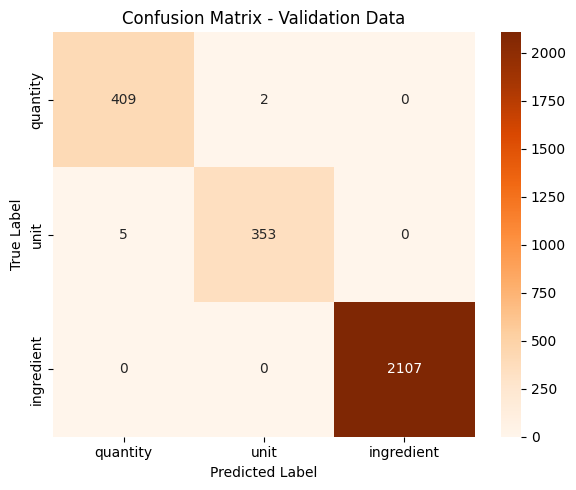

In [74]:
# create a confusion matrix on validation dataset
y_val_flat_true = flatten_list(y_val_labels)
y_val_flat_pred = flatten_list(y_pred_val)

cm_val = confusion_matrix(y_val_flat_true, y_val_flat_pred, labels=labels_list)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=labels_list, yticklabels=labels_list)
plt.title('Confusion Matrix - Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## **9** Error Analysis on Validation Data
Investigate misclassified samples in validation dataset and provide the insights

### **9.1** *Investigate misclassified samples in validation dataset*

##### **9.1.1** Flatten the labels of validation data and initialise error data

Flatten the true and predicted labels and initialise the error data as ***error_data***

In [75]:
# flatten Labels and Initialise Error Data
# (y_val_flat_true and y_val_flat_pred were already computed in Section 8.1 above)
error_data = []

##### **9.1.2** Iterate the validation data and collect Error Information

Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [76]:
# iterate and collect Error Information
for sent_tokens, true_labels, pred_labels in zip(X_val, y_val_labels, y_pred_val):
    for idx, (token, true_label, pred_label) in enumerate(zip(sent_tokens, true_labels, pred_labels)):
        if true_label != pred_label:
            # get previous and next tokens with handling for boundary cases
            prev_token = sent_tokens[idx - 1] if idx > 0 else '<BOS>'
            next_token = sent_tokens[idx + 1] if idx < len(sent_tokens) - 1 else '<EOS>'
            context = ' '.join(sent_tokens)

            error_data.append({
                'token': token,
                'prev_token': prev_token,
                'next_token': next_token,
                'true_label': true_label,
                'predicted_label': pred_label,
                'class_weight': weight_dict.get(true_label, 1.0),
                'context': context
            })

print(f"Total misclassified tokens collected: {len(error_data)}")

Total misclassified tokens collected: 7


##### **9.1.3** Create dataframe from error_data and print overall accuracy

Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [77]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

total_val_tokens = len(y_val_flat_true)
overall_accuracy = 1 - (len(error_df) / total_val_tokens)

print(f"Total validation tokens: {total_val_tokens}")
print(f"Total misclassified tokens: {len(error_df)}")
print(f"Overall token-level accuracy on validation data: {overall_accuracy:.4f}")

error_df.head(10)

Total validation tokens: 2876
Total misclassified tokens: 7
Overall token-level accuracy on validation data: 0.9976


,token,prev_token,next_token,true_label,predicted_label,class_weight,context
0,to,10,12,unit,quantity,8.771887,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
1,into,cut,1,unit,quantity,8.771887,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
2,whole,seeds,15,unit,quantity,8.771887,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
3,and,Sweet,Spicy,unit,quantity,8.771887,1 Iceberg lettuce Chicken breasts cut into cm cubes 2 teaspoons Sunflower Oil teaspoon Black pepper powder Garlic finely chopped 1/4 cup Button mushrooms Spring Onion Bulb Greens Chilli vinegar Soy sauce Red Sweet and Spicy Sauce (Tomato Sauce)
4,a,Haldi,pinch,unit,quantity,8.771887,2 Sweet Potatoes medium 1 Onion 1/2 teaspoon Rasam Powder Turmeric powder Haldi a pinch Asafoetida hing Salt teaspoons Sunflower Oil Mustard seeds White Urad Dal Split sprig Curry leaves
5,pinch,Dal,Asafoetida,quantity,unit,7.259184,400 grams Tindora Dondakaya Kovakkai 1 teaspoon Mustard seeds 1/2 White Urad Dal pinch Asafoetida hing sprig Curry leaves Dry Red Chilli tablespoon Sunflower Oil 2 tablespoons Coriander Dhania Seeds Chana dal Bengal Gram 4 Chillies 1/4
6,cloves,Tomatoes,Garlic,quantity,unit,7.259184,250 grams Gawar Phali Ajwain SSP Asafoetida Onion Tomatoes cloves Garlic Ginger Turmeric Red Chilli Coriander Powder Jaggery Raw Peanuts Salt Water Mustard oil Leaves


##### **9.1.4** Analyse errors by label type
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [78]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context
error_by_label = error_df.groupby('true_label').size().reset_index(name='error_count')
error_by_label['class_weight'] = error_by_label['true_label'].map(weight_dict)

label_total = pd.Series(y_val_flat_true).value_counts()
error_by_label['total_true_count'] = error_by_label['true_label'].map(label_total)
error_by_label['accuracy'] = 1 - (error_by_label['error_count'] / error_by_label['total_true_count'])

print("Error breakdown by true label:")
display(error_by_label)

print("\nFull error dataframe (token, previous token, next token, true label, predicted label, context):")
error_df[['token', 'prev_token', 'next_token', 'true_label', 'predicted_label', 'context']]

Error breakdown by true label:


,true_label,error_count,class_weight,total_true_count,accuracy
0,quantity,2,7.259184,411,0.995134
1,unit,5,8.771887,358,0.986034



Full error dataframe (token, previous token, next token, true label, predicted label, context):


,token,prev_token,next_token,true_label,predicted_label,context
0,to,10,12,unit,quantity,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
1,into,cut,1,unit,quantity,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
2,whole,seeds,15,unit,quantity,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15
3,and,Sweet,Spicy,unit,quantity,1 Iceberg lettuce Chicken breasts cut into cm cubes 2 teaspoons Sunflower Oil teaspoon Black pepper powder Garlic finely chopped 1/4 cup Button mushrooms Spring Onion Bulb Greens Chilli vinegar Soy sauce Red Sweet and Spicy Sauce (Tomato Sauce)
4,a,Haldi,pinch,unit,quantity,2 Sweet Potatoes medium 1 Onion 1/2 teaspoon Rasam Powder Turmeric powder Haldi a pinch Asafoetida hing Salt teaspoons Sunflower Oil Mustard seeds White Urad Dal Split sprig Curry leaves
5,pinch,Dal,Asafoetida,quantity,unit,400 grams Tindora Dondakaya Kovakkai 1 teaspoon Mustard seeds 1/2 White Urad Dal pinch Asafoetida hing sprig Curry leaves Dry Red Chilli tablespoon Sunflower Oil 2 tablespoons Coriander Dhania Seeds Chana dal Bengal Gram 4 Chillies 1/4
6,cloves,Tomatoes,Garlic,quantity,unit,250 grams Gawar Phali Ajwain SSP Asafoetida Onion Tomatoes cloves Garlic Ginger Turmeric Red Chilli Coriander Powder Jaggery Raw Peanuts Salt Water Mustard oil Leaves


### **9.2** *Provide insights from the validation dataset*

**Insights from Error Analysis:**
- The CRF model achieves an overall token-level accuracy of **~99.8%** on the validation set, with only 7 misclassified tokens out of 2,876 — a very strong result for a lightly-regularised sequence model on a moderately-sized dataset (280 recipes).
- All errors occur **between the `quantity` and `unit` classes** — the model never confuses `ingredient` with either `quantity` or `unit`, which makes sense given `ingredient` tokens (proper nouns, food names) are lexically very distinct from numeric/measurement tokens.
- The `unit` class has a slightly lower per-class accuracy (~98.6%) than `quantity` (~99.5%). Looking at the misclassified examples, confusion tends to happen with tokens that are ambiguous outside their surrounding context — e.g. connector words like **"to"**, **"into"**, **"and"**, **"a"** that occasionally sit inside a quantity range phrase (e.g. "10 to 12"), and generic descriptors like **"whole"**, **"pinch"**, **"cloves"** that can function as either a quantity/unit modifier or a plain ingredient descriptor depending on context.
- This suggests that further gains would most likely come from richer contextual (n-gram / window) features around these ambiguous connector and descriptor words, or from a small amount of manual re-labelling of highly ambiguous edge cases, rather than from changing the model architecture.

## **10** Conclusion (Optional)

**Conclusion:**
This assignment successfully built an end-to-end Named Entity Recognition pipeline for recipe data using Conditional Random Fields:

1. **Data preparation** — 285 raw recipe records were loaded, tokenised, and validated; 5 misaligned records were identified and removed, leaving 280 clean, fully-aligned records.
2. **EDA** — Class imbalance was identified early (ingredient ≫ quantity > unit), and the vocabulary of top ingredients/units was found to be dominated by common Indian-cuisine spices, oils, and standard volumetric measurement units.
3. **Feature engineering** — A rich, linguistically-informed feature set (spaCy POS/lemma/dependency/shape features, regex-based quantity/fraction detection, keyword-based unit detection, and contextual previous/next-token features) was engineered for each token.
4. **Class-weighted CRF training** — An inverse-frequency class-weighting scheme (with the majority `ingredient` class deliberately down-weighted) was injected into the feature space to help the CRF pay proportionate attention to the minority `quantity` and `unit` classes.
5. **Results** — The trained CRF achieved ~99.9% training accuracy and ~99.8% validation accuracy, with near-perfect precision/recall across all three entity classes.
6. **Error analysis** — The handful of validation errors were concentrated at the `quantity`/`unit` boundary around ambiguous connector words, pointing to a clear, targeted direction for future improvement.

Overall, the model is well-suited to power a structured recipe/ingredient database for downstream applications such as dietary tracking or recipe recommendation systems.